In [1]:
from pathlib import Path

import pandas as pd
from tqdm import tqdm

from utils import (
    asymmetric_late_prediction_weights,
    time_to_event_training_weights,
    train_models_for_target,
)

/home/aj/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration

In [2]:
DATA_DIR = Path("output")
CSV_PATTERN = "dataset_winsize*.csv"

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
EARLY_PREDICTION_COST = 1.0
LATE_PREDICTION_COST = 5.0


def regression_metric_weight_fn(y_true, y_pred):
    return asymmetric_late_prediction_weights(
        y_true,
        y_pred,
        early_prediction_cost=EARLY_PREDICTION_COST,
        late_prediction_cost=LATE_PREDICTION_COST,
    )


REGRESSION_WEIGHTING_RUNS = [
    {
        "weighting_name": "unweighted",
        "sample_weight_fn": None,
        "metric_weight_fn": regression_metric_weight_fn,
    },
    {
        "weighting_name": "weighted",
        "sample_weight_fn": lambda y: time_to_event_training_weights(
            y,
            early_prediction_cost=EARLY_PREDICTION_COST,
            late_prediction_cost=LATE_PREDICTION_COST,
        ),
        "metric_weight_fn": regression_metric_weight_fn,
    },
]

TARGETS = {
    "label_time_to_event_seconds": "regression",
    "label_from_zone": "classification",
    "label_to_zone": "classification",
}

DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]

SUMMARY_FILENAME = "all_metrics_summary.csv"

MODEL_LABELS = {"tree": "Tree", "rf": "Random Forest"}

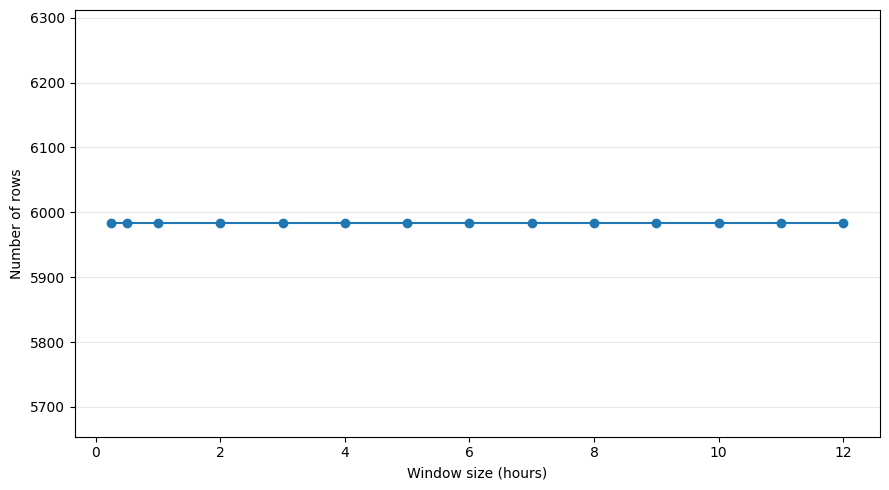

,dataset,winsize,winsize_hours,num_rows
0,dataset_winsize0.25h,0.25,0.25,5983
1,dataset_winsize0.5h,0.5,0.50,5983
2,dataset_winsize1h,1,1.00,5983
3,dataset_winsize2h,2,2.00,5983
4,dataset_winsize3h,3,3.00,5983
5,dataset_winsize4h,4,4.00,5983
6,dataset_winsize5h,5,5.00,5983
7,dataset_winsize6h,6,6.00,5983
8,dataset_winsize7h,7,7.00,5983
9,dataset_winsize8h,8,8.00,5983


In [3]:
import matplotlib.pyplot as plt

row_counts = []

for csv_path in sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h")),
):
    df = pd.read_csv(csv_path)
    winsize = csv_path.stem.split("winsize", 1)[1].removesuffix("h")
    row_counts.append(
        {
            "dataset": csv_path.stem,
            "winsize": winsize,
            "winsize_hours": float(winsize),
            "num_rows": len(df),
        }
    )

row_counts_df = pd.DataFrame(row_counts).sort_values("winsize_hours")

ax = row_counts_df.plot(
    x="winsize_hours",
    y="num_rows",
    kind="line",
    marker="o",
    figsize=(9, 5),
    legend=False,
)
ax.set_xlabel("Window size (hours)")
ax.set_ylabel("Number of rows")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

row_counts_df

In [4]:
############
# RUN ONCE #
############
# Main loop over datasets (takes abut 30 minutes)

# """
all_results = []

csv_files = sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h")),
)

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No files found matching {CSV_PATTERN} in {DATA_DIR.resolve()}"
    )

for csv_path in tqdm(csv_files):
    dataset_name = csv_path.stem
    print(f"\nReading {csv_path}")

    df = pd.read_csv(csv_path)

    for target_col, task_type in TARGETS.items():
        weighting_runs = (
            REGRESSION_WEIGHTING_RUNS
            if task_type == "regression"
            else [
                {
                    "weighting_name": None,
                    "sample_weight_fn": None,
                    "metric_weight_fn": None,
                }
            ]
        )

        for weighting_run in weighting_runs:
            metrics_df = train_models_for_target(
                df=df,
                dataset_name=dataset_name,
                target_col=target_col,
                task_type=task_type,
                output_dir=OUTPUT_DIR,
                random_state=RANDOM_STATE,
                drop_columns=DROP_COLUMNS,
                sample_weight_fn=weighting_run["sample_weight_fn"],
                metric_weight_fn=weighting_run["metric_weight_fn"],
                weighting_name=weighting_run["weighting_name"],
            )

            all_results.append(metrics_df)

final_results = pd.concat(all_results, ignore_index=True)
final_results.to_csv(OUTPUT_DIR / "all_metrics_summary.csv", index=False)

print("\nFinal summary:")
print(final_results)
# """

  0%|          | 0/14 [00:00<?, ?it/s]


Reading output/dataset_winsize0.25h.csv

Dataset: dataset_winsize0.25h
Target: label_time_to_event_seconds
Task: regression
Weighting: unweighted

Training tree...
{'mae': 5325.690109009958, 'median_absolute_error': 737.8834498834499, 'mse': 132982924.74045248, 'rmse': np.float64(11531.822264518842), 'r2': 0.4488599062614649, 'weighted_mae': 4780.276983273515, 'weighted_median_absolute_error': 762.1165501165501, 'weighted_mse': 80796178.8683764, 'weighted_rmse': np.float64(8988.66947152783), 'weighted_r2': 0.262641242306212, 'cost_mae': np.float64(16137.927560073746), 'cost_mse': np.float64(272763039.93910533), 'cost_rmse': np.float64(16515.539347508617), 'cost_mean_weight': np.float64(3.3759398496240602), 'late_prediction_rate': np.float64(0.5939849624060151), 'late_prediction_count': 711}

Top built-in feature importances for tree:
                    feature  importance
15  num_events_last_120_min    0.924697
14   num_events_last_60_min    0.016487
16         node_degree_mean    0.

  7%|▋         | 1/14 [01:09<15:03, 69.47s/it]


Top SHAP importances for rf:
                    feature  mean_abs_shap
16         node_degree_mean       0.006106
3           num_115kv_lines       0.005735
17          node_degree_std       0.005399
4           num_132kv_lines       0.005131
19          node_degree_max       0.004982
15  num_events_last_120_min       0.004960
18          node_degree_min       0.004028
12   num_events_last_15_min       0.003947
14   num_events_last_60_min       0.003799
13   num_events_last_30_min       0.003131

Reading output/dataset_winsize0.5h.csv

Dataset: dataset_winsize0.5h
Target: label_time_to_event_seconds
Task: regression
Weighting: unweighted

Training tree...
{'mae': 5423.761611368275, 'median_absolute_error': 746.0495049504952, 'mse': 136206062.54240373, 'rmse': np.float64(11670.73530427298), 'r2': 0.4355017967615672, 'weighted_mae': 4812.147741315008, 'weighted_median_absolute_error': 667.4566666666669, 'weighted_mse': 82328869.78071831, 'weighted_rmse': np.float64(9073.525763490085), 

 14%|█▍        | 2/14 [02:20<14:04, 70.35s/it]

...


Top SHAP importances for rf:
                    feature  mean_abs_shap
3           num_115kv_lines       0.004803
16         node_degree_mean       0.004682
11         num_unique_buses       0.004153
17          node_degree_std       0.003991
15  num_events_last_120_min       0.003981
1          num_unique_ptids       0.003150
19          node_degree_max       0.002955
9       num_planned_outages       0.002922
0                num_events       0.002873
4           num_132kv_lines       0.002831

Reading output/dataset_winsize11h.csv

Dataset: dataset_winsize11h
Target: label_time_to_event_seconds
Task: regression
Weighting: unweighted

Training tree...
{'mae': 5369.44239979955, 'median_absolute_error': 744.549065420561, 'mse': 137929108.83061448, 'rmse': np.float64(11744.322408322008), 'r2': 0.42836073038290434, 'weighted_mae': 4913.582297276561, 'weighted_median_absolute_error': 861.3260869565202, 'weighted_mse': 83647182.27675492, 'weighted_rmse': np.float64(9145.883351363875), 'w

 93%|█████████▎| 13/14 [17:41<01:26, 86.38s/it]


Top SHAP importances for rf:
                    feature  mean_abs_shap
3           num_115kv_lines       0.004657
16         node_degree_mean       0.004560
11         num_unique_buses       0.004202
17          node_degree_std       0.004146
15  num_events_last_120_min       0.004037
1          num_unique_ptids       0.003163
9       num_planned_outages       0.002943
19          node_degree_max       0.002902
0                num_events       0.002846
4           num_132kv_lines       0.002829

Reading output/dataset_winsize12h.csv

Dataset: dataset_winsize12h
Target: label_time_to_event_seconds
Task: regression
Weighting: unweighted

Training tree...
{'mae': 5366.159001444038, 'median_absolute_error': 743.2539267015709, 'mse': 137958211.40909934, 'rmse': np.float64(11745.561349254422), 'r2': 0.42824011641787463, 'weighted_mae': 4926.43922092648, 'weighted_median_absolute_error': 809.7116788321164, 'weighted_mse': 87964581.79279418, 'weighted_rmse': np.float64(9378.94353287161), 'w

100%|██████████| 14/14 [19:10<00:00, 82.19s/it]


Top SHAP importances for rf:
                    feature  mean_abs_shap
16         node_degree_mean       0.004647
17          node_degree_std       0.004378
3           num_115kv_lines       0.004335
15  num_events_last_120_min       0.004030
11         num_unique_buses       0.003796
9       num_planned_outages       0.003169
19          node_degree_max       0.002967
14   num_events_last_60_min       0.002894
0                num_events       0.002879
1          num_unique_ptids       0.002717

Final summary:
             mae  median_absolute_error           mse          rmse        r2  \
0    5325.690109             737.883450  1.329829e+08  11531.822265  0.448860   
1    5430.596127             698.811668  1.371170e+08  11709.698329  0.431726   
2    5118.718662             738.903930  1.304404e+08  11421.048652  0.459397   
3    5311.689960             721.545663  1.370914e+08  11708.605096  0.431832   
4            NaN                    NaN           NaN           NaN       Na

In [5]:
metrics_df = pd.read_csv(OUTPUT_DIR / SUMMARY_FILENAME)
metrics_df.head()

,mae,median_absolute_error,mse,rmse,r2,weighted_mae,weighted_median_absolute_error,weighted_mse,weighted_rmse,weighted_r2,...,train_weight_mean,train_weight_max,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,5325.690109,737.883450,1.329829e+08,11531.822265,0.448860,4780.276983,762.116550,8.079618e+07,8988.669472,0.262641,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5430.596127,698.811668,1.371170e+08,11709.698329,0.431726,4926.830261,742.836701,8.576875e+07,9261.141924,0.222249,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5118.718662,738.903930,1.304404e+08,11421.048652,0.459397,4282.322998,738.903930,6.991446e+07,8361.486887,0.355504,...,4.810423,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5311.689960,721.545663,1.370914e+08,11708.605096,0.431832,4582.686680,735.665578,7.814367e+07,8839.891042,0.281230,...,4.810423,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.088555,0.050547,0.052361,0.050547,0.039069,0.12799,0.088555,0.078493


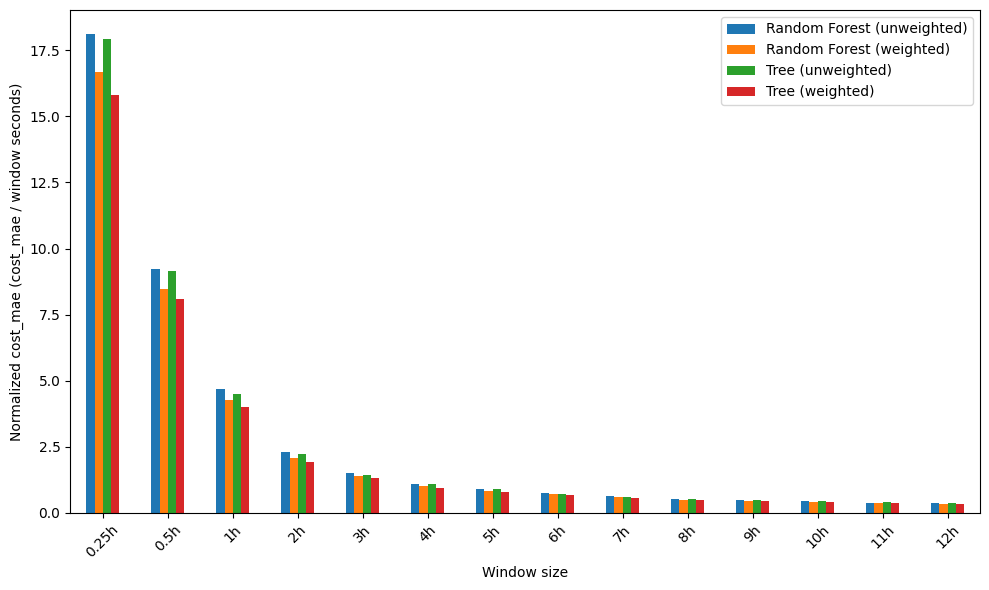

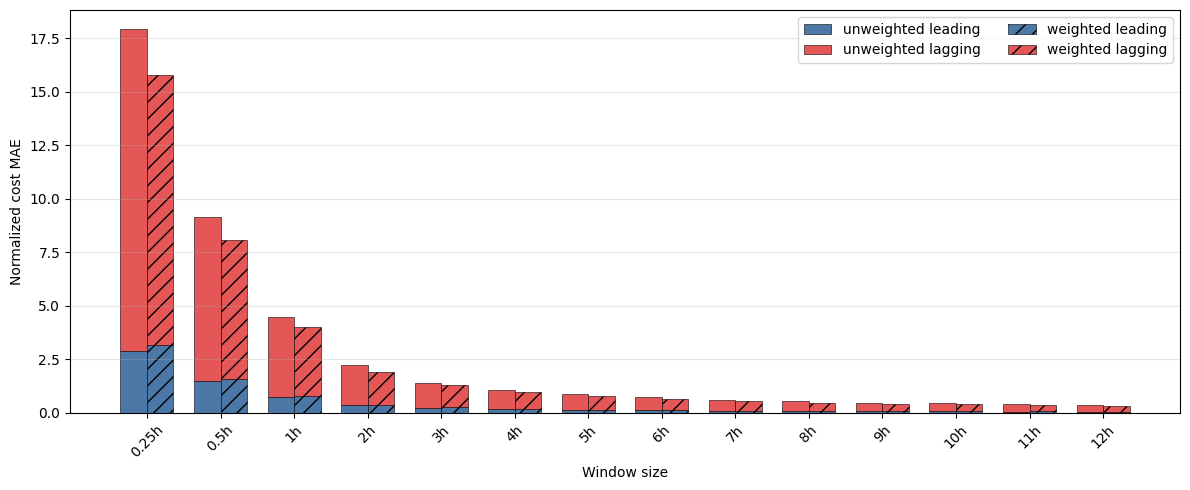

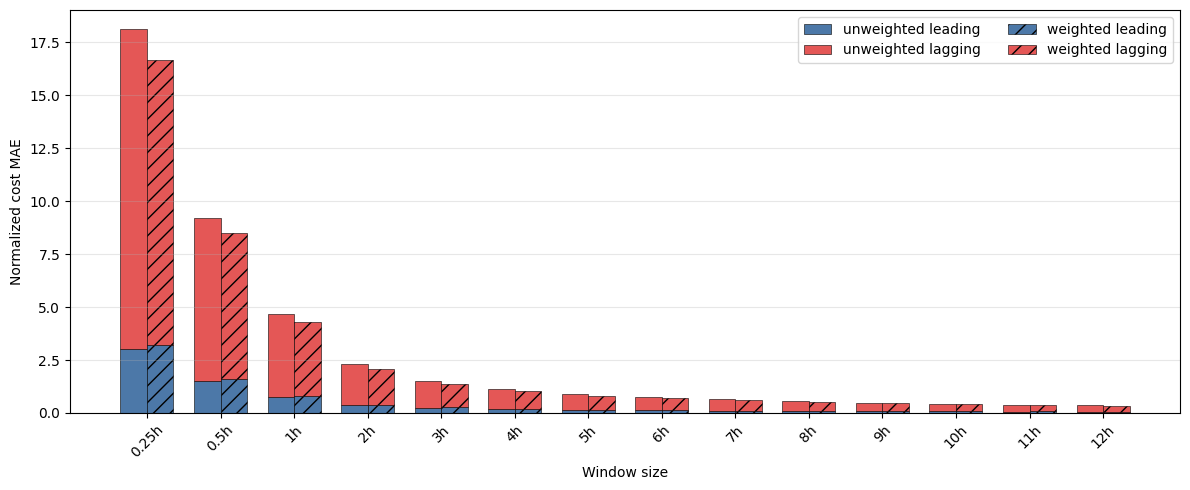

,dataset,winsize,winsize_hours,winsize_seconds,model,weighting,model_run,leading_norm_cost_mae,lagging_norm_cost_mae,normalized_cost_mae,leading_cost_mae_share,lagging_cost_mae_share,lagging_prediction_rate
0,dataset_winsize0.25h,0.25h,0.25,900.0,tree,unweighted,Tree (unweighted),2.914034,15.016996,17.931031,0.162513,0.837487,0.593985
1,dataset_winsize0.25h,0.25h,0.25,900.0,rf,unweighted,Random Forest (unweighted),3.013771,15.101122,18.114893,0.166370,0.833630,0.577277
2,dataset_winsize0.25h,0.25h,0.25,900.0,tree,weighted,Tree (weighted),3.161112,12.631768,15.792880,0.200161,0.799839,0.579783
3,dataset_winsize0.25h,0.25h,0.25,900.0,rf,weighted,Random Forest (weighted),3.211752,13.450630,16.662382,0.192755,0.807245,0.568087
4,dataset_winsize0.5h,0.5h,0.50,1800.0,tree,unweighted,Tree (unweighted),1.481144,7.660284,9.141428,0.162025,0.837975,0.604845


In [6]:
import joblib
import matplotlib.pyplot as plt
import numpy as np

reg_df = metrics_df[
    (metrics_df["task"] == "regression") & (metrics_df["model"].isin(["tree", "rf"]))
].copy()

reg_df["winsize"] = reg_df["dataset"].str.extract(r"winsize(.+)$", expand=False)
reg_df["winsize_hours"] = (
    reg_df["winsize"].str.replace("h", "", regex=False).astype(float)
)
if "weighting" not in reg_df.columns:
    reg_df["weighting"] = "unweighted"

if "cost_mae" in reg_df.columns:
    mae_column = "cost_mae"
elif "weighted_mae" in reg_df.columns:
    mae_column = "weighted_mae"
else:
    mae_column = "mae"
reg_df["winsize_seconds"] = reg_df["winsize_hours"] * 3600
reg_df["mae_norm"] = reg_df[mae_column] / reg_df["winsize_seconds"]
reg_df["model_run"] = (
    reg_df["model"].map(MODEL_LABELS).fillna(reg_df["model"])
    + " ("
    + reg_df["weighting"].fillna("unweighted")
    + ")"
)

reg_df = reg_df.sort_values("winsize_hours")
winsize_order = reg_df.drop_duplicates("winsize")["winsize"]

pivot = reg_df.pivot(
    index="winsize",
    columns="model_run",
    values="mae_norm",
).reindex(winsize_order)

ax = pivot.plot(kind="bar", figsize=(10, 6))
ax.set_xlabel("Window size")
ax.set_ylabel(f"Normalized {mae_column} ({mae_column} / window seconds)")
ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    Path("output") / "regression_mae_norm_bar.pdf", dpi=300, bbox_inches="tight"
)
plt.show()


def regression_error_source_breakdown(regression_rows):
    data_dir = Path("output")
    model_output_dir = Path("model_outputs")
    target_col = "label_time_to_event_seconds"
    rows = []

    for row in regression_rows.itertuples(index=False):
        weighting = getattr(row, "weighting", "unweighted")
        weighting = "unweighted" if pd.isna(weighting) else str(weighting)
        model_path = (
            model_output_dir
            / row.dataset
            / target_col
            / weighting
            / f"{row.model}.joblib"
        )
        if not model_path.exists() and weighting == "unweighted":
            model_path = (
                model_output_dir / row.dataset / target_col / f"{row.model}.joblib"
            )
        if not model_path.exists():
            raise FileNotFoundError(f"Missing saved model: {model_path}")

        df = pd.read_csv(data_dir / f"{row.dataset}.csv")
        test_df = df[df["fold_id"] == -1].copy()
        y_test = test_df[target_col]
        test_mask = y_test.notna()
        y_test = y_test.loc[test_mask].astype(float)

        X_test = test_df.drop(columns=[c for c in DROP_COLUMNS if c in test_df.columns])
        X_test = X_test.select_dtypes(include=[np.number, "bool"]).loc[test_mask]

        model = joblib.load(model_path)
        y_pred = pd.Series(model.predict(X_test), index=y_test.index, dtype=float)
        error = y_pred - y_test

        lagging_mask = error > 0
        absolute_error = error.abs()
        leading_cost_mae = np.where(
            lagging_mask,
            0.0,
            EARLY_PREDICTION_COST * absolute_error,
        ).mean()
        lagging_cost_mae = np.where(
            lagging_mask,
            LATE_PREDICTION_COST * absolute_error,
            0.0,
        ).mean()
        total_cost_mae = leading_cost_mae + lagging_cost_mae

        rows.append(
            {
                "dataset": row.dataset,
                "winsize": row.winsize,
                "winsize_hours": row.winsize_hours,
                "winsize_seconds": row.winsize_hours * 3600,
                "model": row.model,
                "weighting": weighting,
                "model_run": row.model_run,
                "leading_norm_cost_mae": (
                    leading_cost_mae / (row.winsize_hours * 3600)
                ),
                "lagging_norm_cost_mae": (
                    lagging_cost_mae / (row.winsize_hours * 3600)
                ),
                "normalized_cost_mae": total_cost_mae / (row.winsize_hours * 3600),
                "leading_cost_mae_share": (
                    leading_cost_mae / total_cost_mae if total_cost_mae > 0 else 0.0
                ),
                "lagging_cost_mae_share": (
                    lagging_cost_mae / total_cost_mae if total_cost_mae > 0 else 0.0
                ),
                "lagging_prediction_rate": lagging_mask.mean(),
            }
        )

    return pd.DataFrame(rows)


cost_breakdown_df = regression_error_source_breakdown(reg_df)
cost_breakdown_df.to_csv(
    Path("model_outputs") / "regression_cost_mae_lead_lag_breakdown.csv",
    index=False,
)

model_order = [
    model for model in ["tree", "rf"] if model in cost_breakdown_df["model"].unique()
]
weighting_order = [
    weighting
    for weighting in ["unweighted", "weighted"]
    if weighting in cost_breakdown_df["weighting"].unique()
]
extra_weightings = [
    weighting
    for weighting in cost_breakdown_df["weighting"].unique()
    if weighting not in weighting_order
]
weighting_order.extend(extra_weightings)

x = np.arange(len(winsize_order))
bar_width = 0.36 if len(weighting_order) > 1 else 0.6
offsets = (np.arange(len(weighting_order)) - (len(weighting_order) - 1) / 2) * bar_width
component_colors = {"leading": "#4C78A8", "lagging": "#E45756"}
weighting_hatches = {"unweighted": "", "weighted": "//"}

for model_name in model_order:
    fig, ax = plt.subplots(figsize=(12, 5))
    model_data = cost_breakdown_df[cost_breakdown_df["model"] == model_name]

    for offset, weighting in zip(offsets, weighting_order):
        aligned = (
            model_data[model_data["weighting"] == weighting]
            .set_index("winsize")
            .reindex(winsize_order)
        )
        leading = aligned["leading_norm_cost_mae"].fillna(0.0)
        lagging = aligned["lagging_norm_cost_mae"].fillna(0.0)
        hatch = weighting_hatches.get(weighting, "")
        label_prefix = weighting.replace("_", " ")

        ax.bar(
            x + offset,
            leading,
            width=bar_width,
            color=component_colors["leading"],
            edgecolor="black",
            linewidth=0.4,
            hatch=hatch,
            label=f"{label_prefix} leading",
        )
        ax.bar(
            x + offset,
            lagging,
            width=bar_width,
            bottom=leading,
            color=component_colors["lagging"],
            edgecolor="black",
            linewidth=0.4,
            hatch=hatch,
            label=f"{label_prefix} lagging",
        )

    ax.set_xlabel("Window size")
    ax.set_ylabel("Normalized cost MAE")
    ax.set_xticks(x)
    ax.set_xticklabels(winsize_order, rotation=45)
    ax.legend(ncol=2, loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        Path("output") / f"regression_cost_mae_lead_lag_breakdown_{model_name}.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

cost_breakdown_df.head()

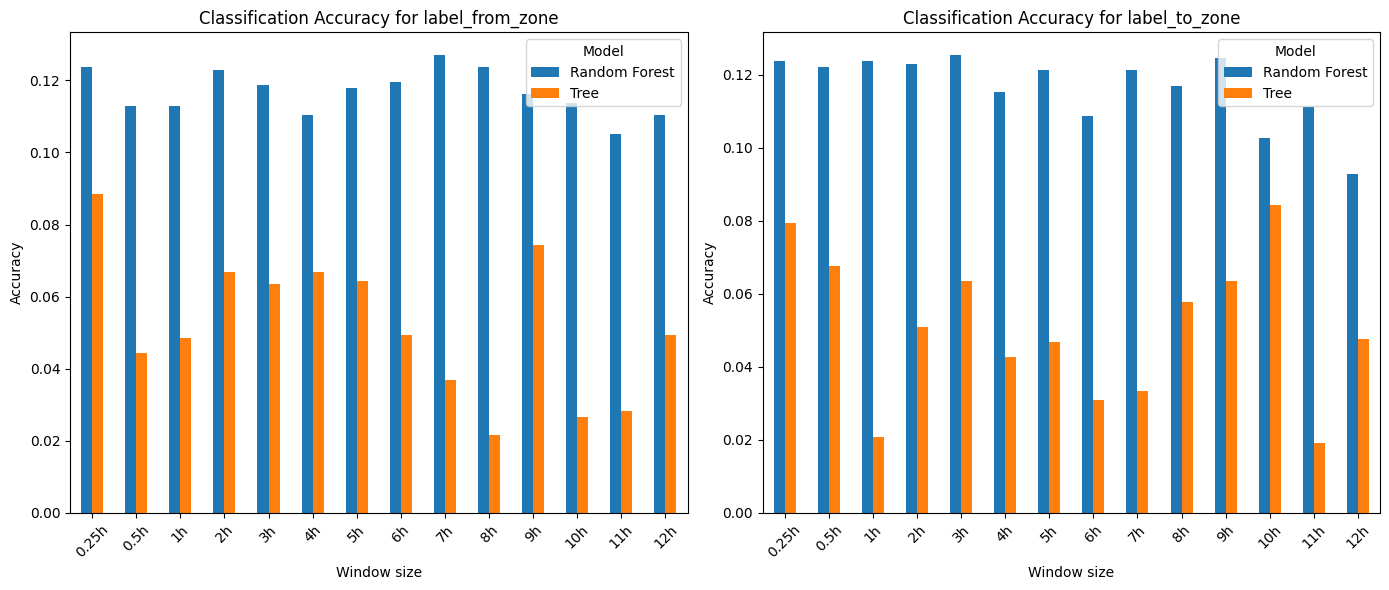

In [7]:
class_df = metrics_df[
    (metrics_df["task"] == "classification")
    & (metrics_df["target"].isin(["label_from_zone", "label_to_zone"]))
    & (metrics_df["model"].isin(["tree", "rf"]))
].copy()

class_df["winsize"] = class_df["dataset"].str.extract(r"winsize(.+)$", expand=False)
class_df["winsize_hours"] = (
    class_df["winsize"].str.replace("h", "", regex=False).astype(float)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, target in enumerate(["label_from_zone", "label_to_zone"]):
    target_data = class_df[class_df["target"] == target].sort_values("winsize_hours")
    winsize_order = target_data.drop_duplicates("winsize")["winsize"]
    pivot = (
        target_data.pivot(index="winsize", columns="model", values="accuracy")
        .reindex(winsize_order)
        .rename(columns=MODEL_LABELS)
    )

    ax = pivot.plot(kind="bar", ax=axes[idx])
    ax.set_xlabel("Window size")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Classification Accuracy for {target}")
    ax.legend(title="Model")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# train a classification model for time intervals
%run train_time_interval_classification.py

             dataset  n_train  n_test  accuracy  balanced_accuracy  interval_weighted_accuracy  balanced_interval_weighted_accuracy  n_[0,1)  n_[1,2)  n_[2,4)  n_[4,8)  n_[8,inf)  accuracy_[0,1)  accuracy_[1,2)  accuracy_[2,4)  accuracy_[4,8)  accuracy_[8,inf)
dataset_winsize0.25h     4786    1197  0.735171           0.604170                    0.912907                             0.866762      538      183      181      179        116             1.0             1.0        0.353591        0.279330          0.387931
 dataset_winsize0.5h     4786    1197  0.741019           0.608933                    0.912281                             0.864726      538      183      181      179        116             1.0             1.0        0.364641        0.335196          0.344828
  dataset_winsize10h     4786    1197  0.750209           0.616208                    0.920217                             0.874003      538      183      181      179        116             1.0             1.0       

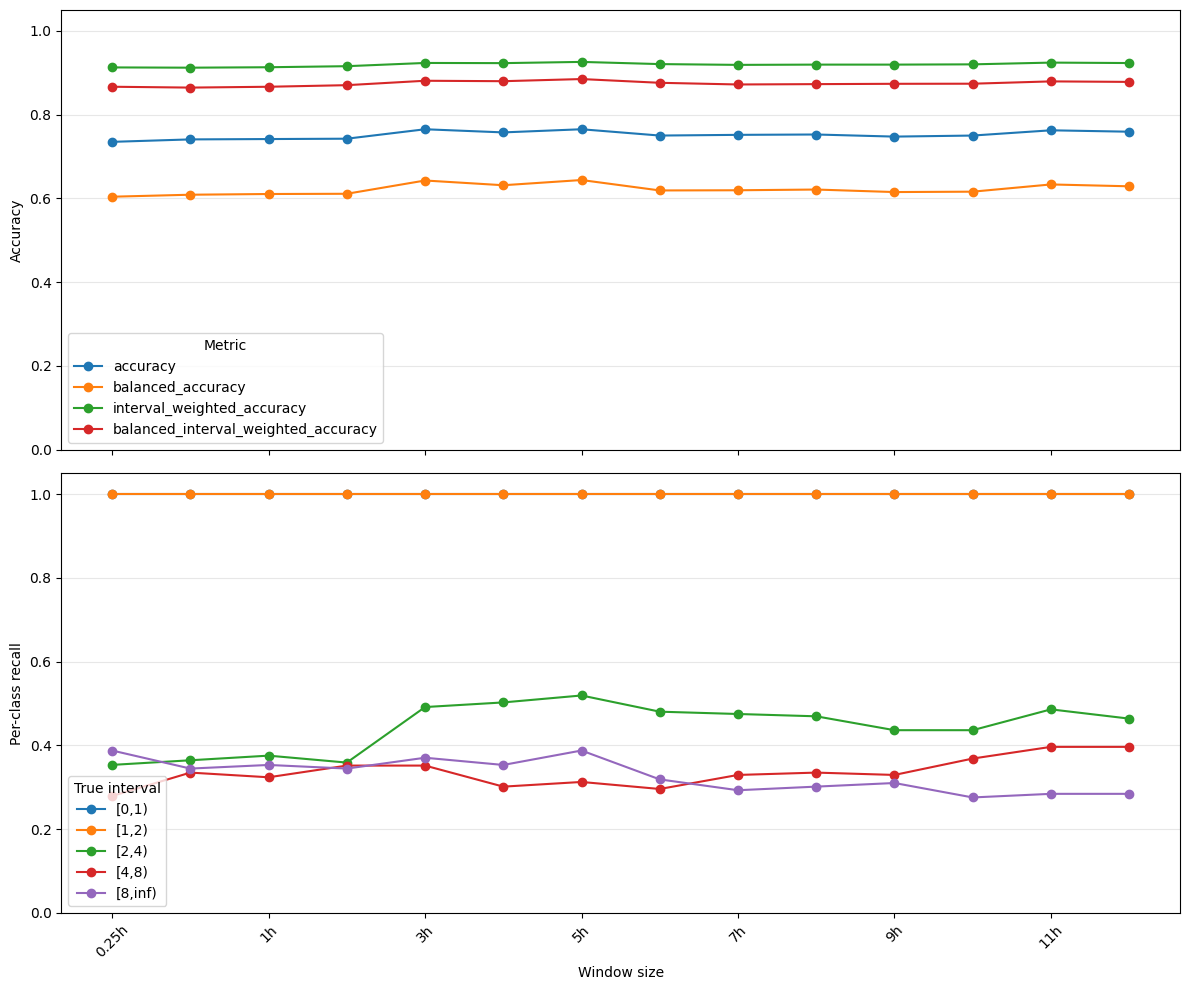

In [9]:
interval_metrics_path = (
    Path("model_outputs") / "time_interval_rf" / "all_interval_metrics.csv"
)
interval_df = pd.read_csv(interval_metrics_path)

interval_df["winsize"] = interval_df["dataset"].str.extract(
    r"winsize(.+)$", expand=False
)
interval_df["winsize_hours"] = (
    interval_df["winsize"].str.replace("h", "", regex=False).astype(float)
)
interval_df = interval_df.sort_values("winsize_hours")

metric_cols = [
    "accuracy",
    "balanced_accuracy",
    "interval_weighted_accuracy",
    "balanced_interval_weighted_accuracy",
]
class_accuracy_cols = [c for c in interval_df.columns if c.startswith("accuracy_[")]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
interval_plot_df = interval_df.set_index("winsize")

interval_plot_df[metric_cols].plot(marker="o", ax=axes[0])
axes[0].set_xlabel("")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].legend(title="Metric", loc="lower left")
axes[0].grid(axis="y", alpha=0.3)

# These columns are per-class recall: correct predictions / true class count.
class_recall = interval_plot_df[class_accuracy_cols]
class_recall.columns = [c.removeprefix("accuracy_") for c in class_recall.columns]
class_recall.plot(marker="o", ax=axes[1])
axes[1].set_xlabel("Window size")
axes[1].set_ylabel("Per-class recall")
axes[1].set_ylim(0, 1.05)
axes[1].legend(title="True interval", loc="lower left")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()